In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import pandas as pd
from attention_classifier import AttentionClassifier

df_3b = pd.read_hdf("../events/MG3/dataframes/threeTag_picoAOD.h5")
df_bg4b = pd.read_hdf("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
df_signal = pd.read_hdf("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]

In [3]:
features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import tqdm

from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle
import pandas as pd


features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

In [8]:
def get_events_tst(hash: str):
    fvt_tinfo = TrainingInfo.load(hash)
    ms_hash = fvt_tinfo.ms_hash
    ms_idx = fvt_tinfo.ms_idx
    msamples = MotherSamples.load(ms_hash)
    tst_scdinfo = msamples.scdinfo[~ms_idx]
    df_tst = tst_scdinfo.fetch_data_with_loaded_df(raw_df_list)
    events_tst = EventsData.from_dataframe(df_tst, features)
    return events_tst

def calculate_SR_stats(events_tst, hash):
    smeared_fvt_tinfo = TrainingInfo.load(hash)
    base_encoder_hash = smeared_fvt_tinfo.hparams["encoder_hash"]
    base_fvt_tinfo = TrainingInfo.load(base_encoder_hash)
    base_fvt_model = base_fvt_tinfo.load_trained_model("best")
    base_fvt_model.eval()
    base_fvt_model: FvTClassifier
    base_fvt_scores, base_q_repr = base_fvt_model.predict_and_representations(events_tst.X_torch)
    base_fvt_scores = base_fvt_scores.numpy()[:, 1]
    base_q_repr = base_q_repr.numpy()
    base_gamma = base_fvt_scores / (1 - base_fvt_scores)
    smeared_fvt_model = smeared_fvt_tinfo.load_trained_model("best")
    smeared_fvt_model.eval()
    smeared_fvt_model.to(torch.device("cuda"))
    smeared_fvt_model: AttentionClassifier
    fvt_smeared = smeared_fvt_model.predict(base_q_repr).numpy()[:, 1]
    gamma_smeared = fvt_smeared / (1 - fvt_smeared)
    SR_stats_tst = np.log(base_gamma / gamma_smeared)
    return SR_stats_tst

def plot_mean_and_fill_between_std(x, y_list, ax, **kwargs):
    y_mean = np.mean(y_list, axis=0)
    y_std = np.std(y_list, axis=0)
    ax.plot(x, y_mean, **kwargs)
    if "color" in kwargs:
        ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.2, color=kwargs["color"])
    else:
        ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.2)

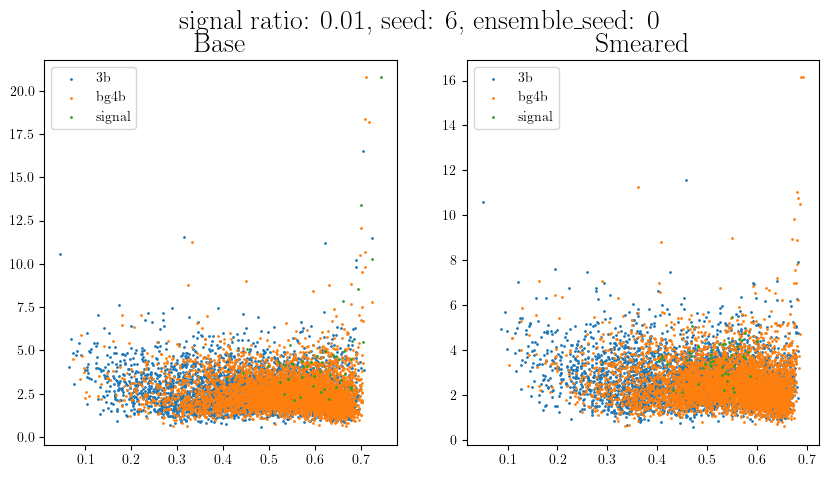

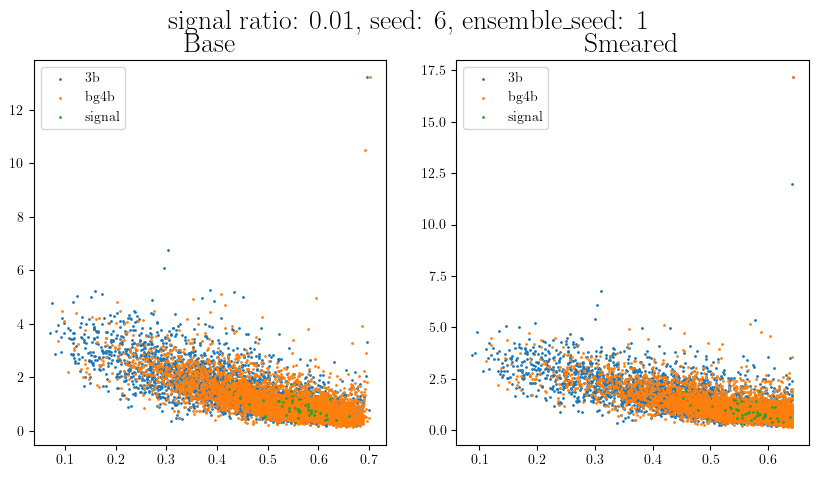

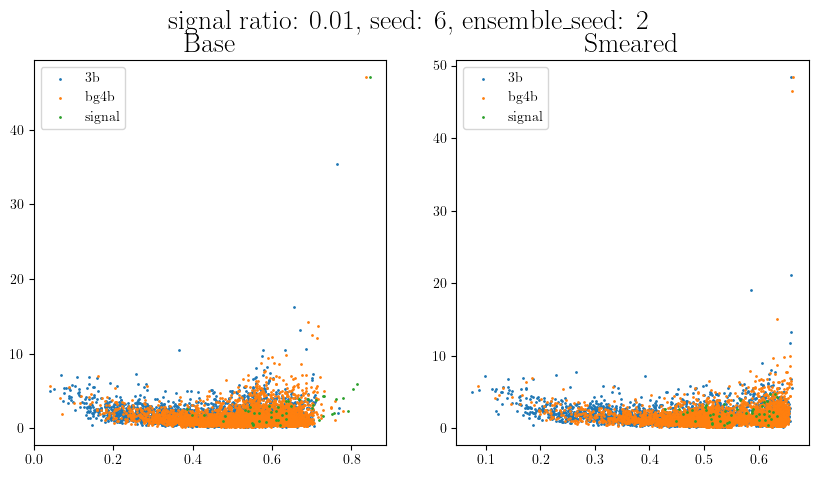

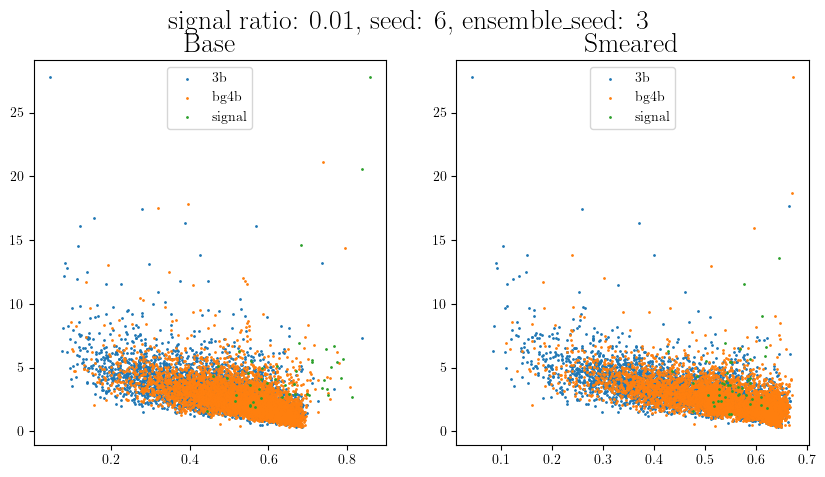

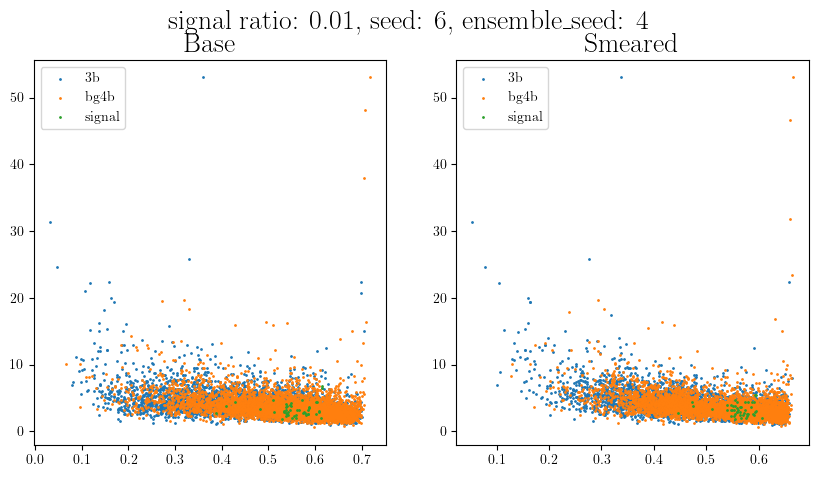

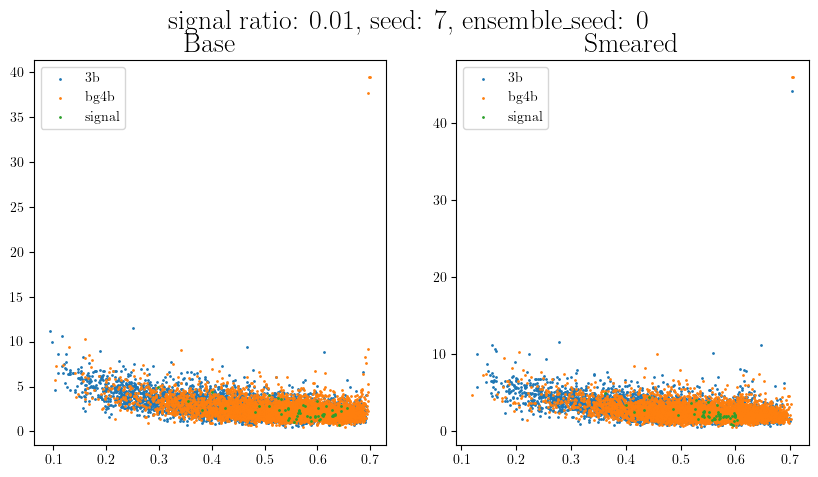

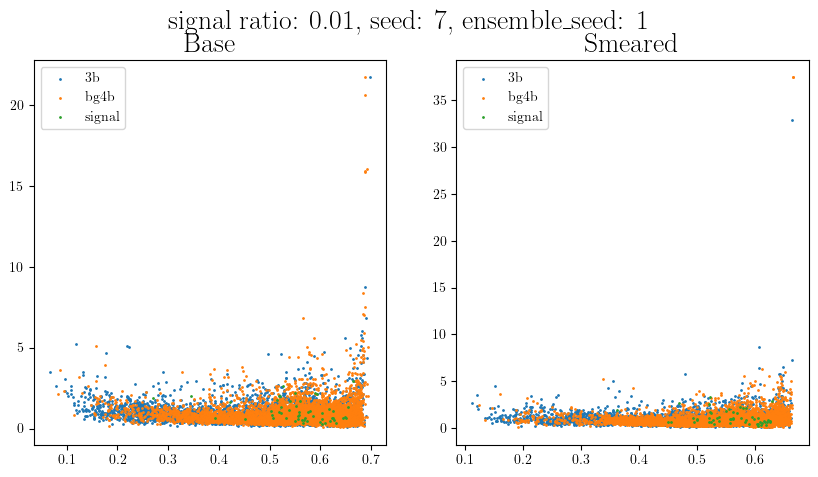

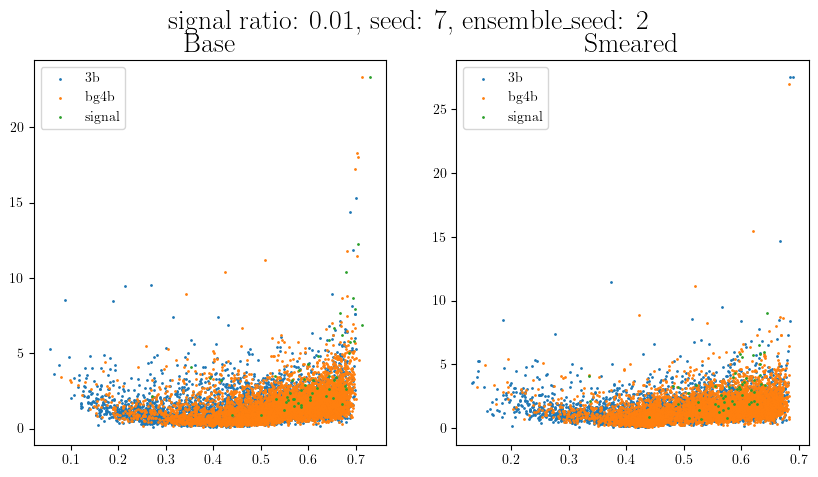

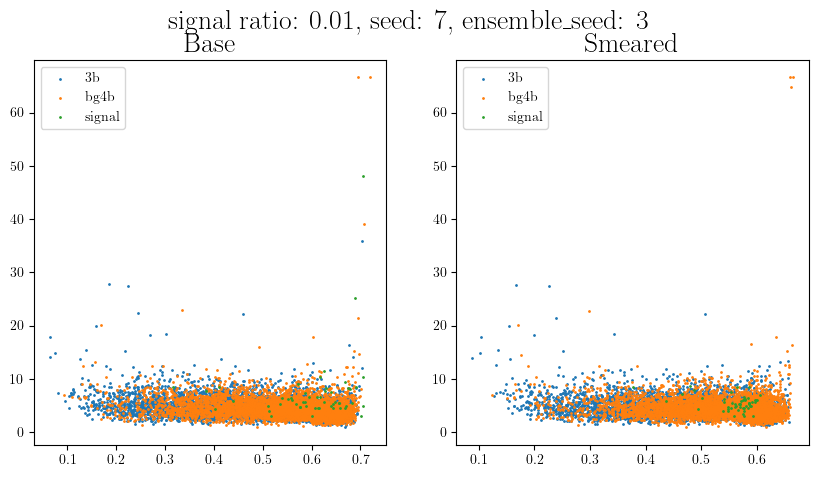

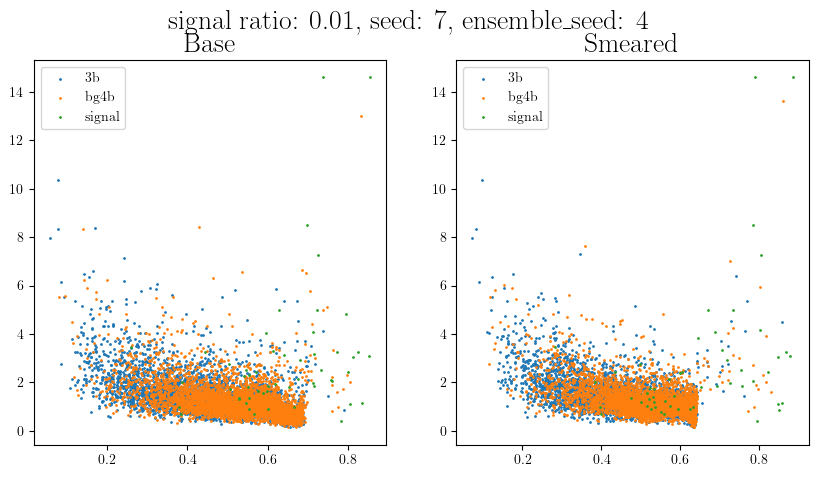

In [26]:
from dist_to_nearest_peak import min_dist_to_others

experiment_name = "smeared_fvt_training_ensemble"
n_3b = 100_0000
n_events = 10_000
peak_pct = 0.025

for signal_ratio in [0.01]:
    for seed in range(6, 8):
        hashes, hparams = TrainingInfo.find({"experiment_name": experiment_name, 
                                                    "dataset": lambda x: (x["signal_ratio"] == signal_ratio 
                                                                        and x["seed"] == seed 
                                                                        and x["n_3b"] == n_3b), 
                                                    }, return_hparams=True)
                # sort hashes by train_seed
        hashes = sorted(hashes, key=lambda x: hparams[hashes.index(x)]["train_seed"])
        events_tst = get_events_tst(hashes[0])
        # shuffle events_tst
        events_tst.shuffle(seed=seed)
        events_sample = events_tst[:n_events]
        is_3b = events_sample.is_3b
        is_bg4b = events_sample.is_bg4b
        is_signal = events_sample.is_signal
        
        for hash in hashes:
            smeared_fvt_tinfo = TrainingInfo.load(hash)
            smeared_fvt_model = smeared_fvt_tinfo.load_trained_model("best")
            smeared_fvt_model.eval()
            smeared_fvt_model: FvTClassifier
            
            base_fvt_tinfo = TrainingInfo.load(smeared_fvt_tinfo.hparams["encoder_hash"])
            base_fvt_model = base_fvt_tinfo.load_trained_model("best")
            base_fvt_model.eval()
            base_fvt_model: FvTClassifier
            
            ensemble_seed = base_fvt_tinfo.hparams["train_seed"]
            
            # randomly sample 10000 events
            base_fvt_scores, base_q_repr = base_fvt_model.predict_and_representations(events_sample.X_torch)
            
            smeared_fvt_scores = smeared_fvt_model.predict(base_q_repr).numpy()[:, 1]
            base_fvt_scores = base_fvt_scores.numpy()[:, 1]
            base_q_repr = base_q_repr.numpy()
            base_q_repr = base_q_repr.reshape(-1, base_q_repr.shape[1] * base_q_repr.shape[2])
            
            base_dists = min_dist_to_others(base_q_repr, 
                                           base_fvt_scores, 
                                           weights=events_sample.weights)
            
            smeared_dists = min_dist_to_others(base_q_repr, 
                                           smeared_fvt_scores, 
                                           weights=events_sample.weights)
            
            
            fig, ax = plt.subplots(1, 2, figsize=(10, 5))
            fig.suptitle(f"signal ratio: {signal_ratio}, seed: {seed}, ensemble_seed: {ensemble_seed}")
            
            ax[0].scatter(base_fvt_scores[is_3b], base_dists[is_3b], s=1, label="3b")
            ax[0].scatter(base_fvt_scores[is_bg4b], base_dists[is_bg4b], s=1, label="bg4b")
            ax[0].scatter(base_fvt_scores[is_signal], base_dists[is_signal], s=1, label="signal")
            ax[0].legend()
            ax[0].set_title("Base")
            
            ax[1].scatter(smeared_fvt_scores[is_3b], smeared_dists[is_3b], s=1, label="3b")
            ax[1].scatter(smeared_fvt_scores[is_bg4b], smeared_dists[is_bg4b], s=1, label="bg4b")
            ax[1].scatter(smeared_fvt_scores[is_signal], smeared_dists[is_signal], s=1, label="signal")
            ax[1].legend()
            ax[1].set_title("Smeared")
            
            plt.show()